In [1]:
import pandas as pd
import tushare as ts
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('./maotai.csv')
df

,Unnamed: 0,ts_code,trade_date,open,high,low,close
0,5348,600519.SH,20010827,34.51,37.78,32.85,35.55
1,5347,600519.SH,20010828,34.99,37.00,34.61,36.86
2,5346,600519.SH,20010829,36.98,37.00,36.10,36.38
3,5345,600519.SH,20010830,36.28,37.51,36.00,37.10
4,5344,600519.SH,20010831,37.15,37.62,36.80,37.01
...,...,...,...,...,...,...,...
5344,4,600519.SH,20231225,1671.00,1678.60,1668.00,1672.00
5345,3,600519.SH,20231226,1672.50,1674.90,1657.50,1670.00
5346,2,600519.SH,20231227,1668.00,1677.15,1661.00,1667.06
5347,1,600519.SH,20231228,1670.99,1727.99,1667.06,1724.99


In [3]:
df.drop(labels='Unnamed: 0',axis=1,inplace=True)

In [4]:
df

,ts_code,trade_date,open,high,low,close
0,600519.SH,20010827,34.51,37.78,32.85,35.55
1,600519.SH,20010828,34.99,37.00,34.61,36.86
2,600519.SH,20010829,36.98,37.00,36.10,36.38
3,600519.SH,20010830,36.28,37.51,36.00,37.10
4,600519.SH,20010831,37.15,37.62,36.80,37.01
...,...,...,...,...,...,...
5344,600519.SH,20231225,1671.00,1678.60,1668.00,1672.00
5345,600519.SH,20231226,1672.50,1674.90,1657.50,1670.00
5346,600519.SH,20231227,1668.00,1677.15,1661.00,1667.06
5347,600519.SH,20231228,1670.99,1727.99,1667.06,1724.99


In [5]:
df.rename(columns={'trade_date':'date'},inplace=True)

In [6]:
df

,ts_code,date,open,high,low,close
0,600519.SH,20010827,34.51,37.78,32.85,35.55
1,600519.SH,20010828,34.99,37.00,34.61,36.86
2,600519.SH,20010829,36.98,37.00,36.10,36.38
3,600519.SH,20010830,36.28,37.51,36.00,37.10
4,600519.SH,20010831,37.15,37.62,36.80,37.01
...,...,...,...,...,...,...
5344,600519.SH,20231225,1671.00,1678.60,1668.00,1672.00
5345,600519.SH,20231226,1672.50,1674.90,1657.50,1670.00
5346,600519.SH,20231227,1668.00,1677.15,1661.00,1667.06
5347,600519.SH,20231228,1670.99,1727.99,1667.06,1724.99


In [7]:
#将date转化为时间
df['date'] = pd.to_datetime(df['date'],format='%Y%m%d')
print(df)

        ts_code       date     open     high      low    close
0     600519.SH 2001-08-27    34.51    37.78    32.85    35.55
1     600519.SH 2001-08-28    34.99    37.00    34.61    36.86
2     600519.SH 2001-08-29    36.98    37.00    36.10    36.38
3     600519.SH 2001-08-30    36.28    37.51    36.00    37.10
4     600519.SH 2001-08-31    37.15    37.62    36.80    37.01
...         ...        ...      ...      ...      ...      ...
5344  600519.SH 2023-12-25  1671.00  1678.60  1668.00  1672.00
5345  600519.SH 2023-12-26  1672.50  1674.90  1657.50  1670.00
5346  600519.SH 2023-12-27  1668.00  1677.15  1661.00  1667.06
5347  600519.SH 2023-12-28  1670.99  1727.99  1667.06  1724.99
5348  600519.SH 2023-12-29  1720.00  1749.58  1720.00  1726.00

[5349 rows x 6 columns]


In [8]:
df.set_index('date',inplace=True)

In [9]:
ma5 = df['close'].rolling(5).mean()
ma30 = df['close'].rolling(30).mean()

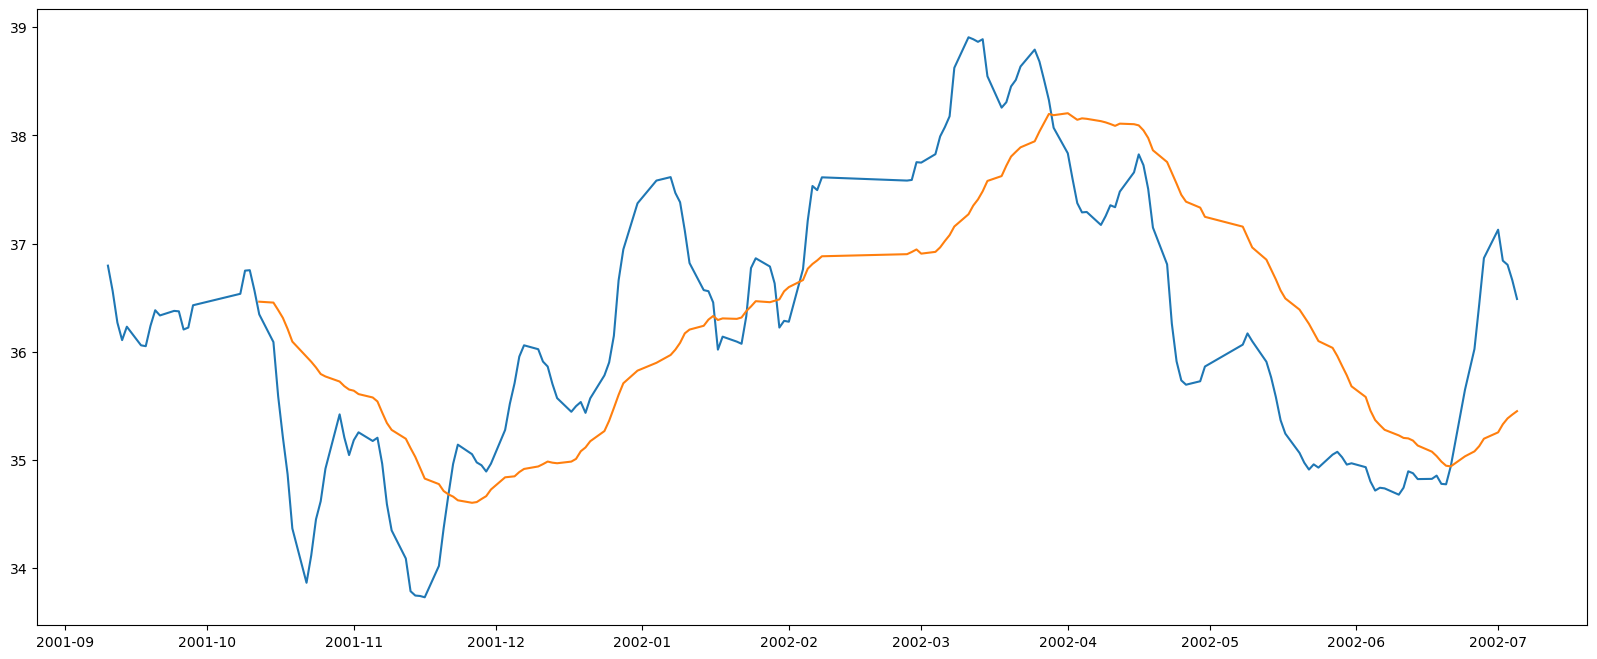

In [10]:
plt.figure(figsize=(20,8),dpi=100)
plt.plot(ma5[10:200])
plt.plot(ma30[10:200])

In [11]:
ma5=ma5[30:]
ma30=ma30[30:]
s1 = ma5 < ma30
s2 = ma5 > ma30

In [12]:
df=df[30:]

In [13]:
death_ex=s1&s2.shift(1)#判断死叉条件
df.loc[death_ex]#取死叉对应的数据
death_date=df.loc[death_ex].index
death_date

DatetimeIndex(['2002-01-17', '2002-01-30', '2002-03-29', '2002-07-25',
               '2002-12-27', '2003-03-17', '2003-04-22', '2003-06-20',
               '2003-06-30', '2004-02-27',
               ...
               '2022-05-13', '2022-07-18', '2022-10-10', '2023-02-08',
               '2023-02-23', '2023-04-12', '2023-08-21', '2023-09-11',
               '2023-09-26', '2023-12-05'],
              dtype='datetime64[ns]', name='date', length=117, freq=None)

In [14]:
golden_ex = ~(s1|s2.shift(1))#判断金叉条件
golden_date = df.loc[golden_ex].index

# 策略
买卖股票的单价使用开盘价
买卖股票的时间
手中会有剩余股票：计算剩余股票的单价用收盘价

In [15]:
s1 = pd.Series(data=1,index=golden_date)#1作为金叉的标识
s2 = pd.Series(data=0,index=death_date)#0为死叉的标识
s = s1._append(s2)
s = s.sort_index()#存储的金叉与死叉的时间
s=s['2010':'2020']
s

date
2010-01-20    1
2010-01-22    0
2010-02-03    1
2010-02-26    0
2010-06-04    1
             ..
2020-08-19    1
2020-09-21    0
2020-10-14    1
2020-10-27    0
2020-11-05    1
Length: 119, dtype: int64

In [16]:
first_money =100000#本金，不变
money = first_money#可变的
hold=0#持有股票的数量（股数：100股=1手）
for i in range(0,len(s)):#i为隐式索引
    #i=0(死叉：卖) or （金叉：买）
    if s[i] == 1:
        #基于100000的本金尽可能多的买股票
        #获取股票的单价（金叉对应的开盘价）
        golden_time = s.index[i]#金叉的索引
        p_golden =df.loc[golden_time]['open']#金叉的开盘价
        hand_count =  money //( p_golden*100)#使用100000最多买多少手
        hold = hand_count * 100
        money -=(hold * p_golden)#将买股票花的钱减去
    else:
        #卖股票
        #找出死叉时间
        death_time = s.index[i]
        p_death = df.loc[death_time]['open']#死叉的开盘价
        money += ( p_death * hold)#卖出股票的收入
        hold =0
print(money)
#如何判断最后一天是金叉还是死叉
last_money = hold *df['close'][-1]#剩余股票的价值
#总收益
money = last_money + first_money
print(money)

106193.0
1135600.0


C:\Users\86157\AppData\Local\Temp\ipykernel_34792\2124996822.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if s[i] == 1:
C:\Users\86157\AppData\Local\Temp\ipykernel_34792\2124996822.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  last_money = hold *df['close'][-1]#剩余股票的价值
